In [1]:
import numpy as np
import scipy as sp
import gprob as gp

import matplotlib.pyplot as plt

np.random.seed(0)

The Cramer-Rao bound is a central result in parameter estimation theory. Given a family of probability distributions $p_\theta(x)$ of a random variable $x$ depending on a continuous parameter $\theta$, the Cramer-Rao bound gives the minimum uncertainty of unbiased estimation of $\theta$ from the distribution samples. The bound is expressed via the Fisher information $I_\mathrm{F}(\theta)$ as 
\begin{equation*}
\left\langle(\theta_\mathrm{est}(x)-\theta)^2\right\rangle \ge \frac{1}{N I_\mathrm{F}(\theta)},
\end{equation*}
where $N$ is the number of samples, and $\theta_\mathrm{est}(x)$ is an unbiased estimator of $\theta$, i.e. such that $\langle \theta_\mathrm{est}(x) \rangle=\theta$.
The Fisher information is defined as
\begin{equation*}
I_\mathrm{F}(\theta)=\left\langle\left(\frac{\partial}{\partial \theta} \log\,p_\theta(x)\right)^2\right\rangle.
\end{equation*}

This notebook calculates the Cramer-Rao bound for a parameter estimation problem using the relation of the Fisher information to the Kullback-Leibler divergence,
\begin{equation*}
I_\mathrm{F}(\theta) = \left.\frac{\partial^2}{\partial\alpha^2}D_\mathrm{KL}\big(p_\theta(x)||p_{\theta+\alpha}(x)\big)\right|_{\alpha=0},
\end{equation*}
and compares it to the variance of a practical estimator.

# Cramer-Rao bound for the estimation of damping

Consider an Ornstein–Uhlenbeck process with a unknown damping rate $\gamma$,
\begin{align*}
&\frac{d}{dt}x(t)=-\gamma x(t) + \xi(t),
&x(0)=x_0,
\end{align*}
where $t\in [0, 2]$ is the time, $x_0$ is a known inital condition, and $\xi(t)$ is a white noise process with $\langle \xi(t+\tau)\xi(t) \rangle=\delta(\tau)$. 

Given several stochastic trajectories from this Ornstein–Uhlenbeck process, we want to estimate $\gamma$, and find the minimum error variance of the estimation.

First, we introduce some basic quantities, such as the time grid, the Wiener increments, and the (random) initial condition:

In [2]:
sz = 1001
t = np.linspace(0, 2, sz)                  # Temporal grid.
dt = (t[-1] - t[0]) / (len(t) - 1)         # Time step.
xi = np.sqrt(dt) * gp.normal(size=(sz-1))  # Wiener increments.
x0 = 0.1 * gp.normal()                     # Initial condition.

Next, using the Green-function-based solution for $x(t)$,
\begin{equation*}
x(t)=e^{-\gamma t}x(0)+\int_0^t e^{-\gamma(t-t')}\xi(t') dt',
\end{equation*}
we define a function ``ou_process`` that produces a discrete approximation of the Ornstein–Uhlenbeck process for a given $\gamma$:

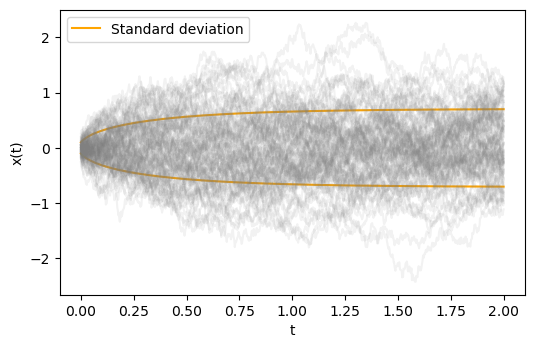

In [ ]:
def ou_process(gamma):
    """A discrete approximation of the the Ornstein-Uhlenbeck process precise 
    to the second order in dt."""

    green = np.exp(-gamma * t)
    s = gp.cumsum(0.5 * (1/green[1:] + 1/green[:-1]) * xi)
    s = x0 + gp.concatenate([[0], s])
    return green * s


gamma0 = 1  # This will be the true value of the damping rate.
x = ou_process(gamma0)

plt.figure(figsize=(6, 3.7))
plt.plot(t, x.std(), color="orange", label="Standard deviation")
plt.plot(t, -x.std(), color="orange")
plt.plot(t, x.sample(100).T, color="gray", alpha=0.1)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend();

For the computation of the Fisher information, we numerically find the second derivative of $D_\mathrm{KL}$:

In [4]:
alpha = 1e-3

xp = ou_process(gamma0 + alpha)
xm = ou_process(gamma0 - alpha)

fi = (gp.dkl(x, xp) + gp.dkl(x, xm)) / alpha**2

print(f"Fisher information: {fi}")
print(f"Lowest standard deviation of the estimation error: {1/np.sqrt(fi)}")

Fisher information: 0.759483668844041
Lowest standard deviation of the estimation error: 1.1474685209391269


Note that the first derivative of $D_\mathrm{KL}$ is zero,
\begin{equation*}
\left.\frac{\partial}{\partial\alpha}D_\mathrm{KL}\big(p_\theta(x)||p_{\theta+\alpha}(x)\big)\right|_{\alpha=0}=0,
\end{equation*} 
because of the normalization of the probability distribution. The practical consequence of this is that the numeric step $\alpha$ should not be too small, as $D_\mathrm{KL}$ depends on it only quadratically.

In [5]:
(gp.dkl(x, xp) - gp.dkl(x, xm)) / (2 * alpha)  # The first derivative of D_KL.

1.7053025658242404e-10

We now construct a simply-minded estimator of $\gamma$ that works by fitting the theoretical model of the variance of $x$ versus time,
\begin{equation*}
\left\langle x^2(t)\right\rangle = \left\langle x^2_0\right\rangle e^{-2\gamma t} + \frac{1}{2\gamma}\left(1 - e^{-2\gamma t}\right).
\end{equation*}
to the variance of $x$ calculated from the sampled trajectories. (This estimator does have a little bias, but it will be shown to be negligible.) 

Estimated value of gamma: 1.1765614475715929


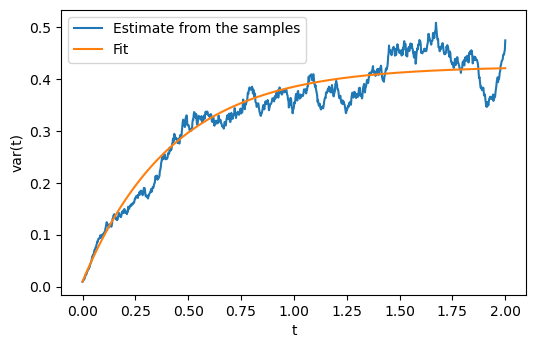

In [6]:
def var_model(t, gamma):
    return x0.var() * np.exp(-2 * t * gamma) + 1 / (2 * gamma) * (1 - np.exp(-2 * t * gamma))


def estimate_var(samples):
    return np.sum(samples**2, axis=0) / len(samples)


def estimate_gamma(samples):
    var_est = estimate_var(samples)
    popt, _ = sp.optimize.curve_fit(var_model, t, var_est, p0=[1])
    return popt[0]


nsamples = 100
samples = x.sample(nsamples)
gamma_e = estimate_gamma(samples)

print(f"Estimated value of gamma: {gamma_e}")

plt.figure(figsize=(6, 3.7))
plt.plot(t, estimate_var(samples), label="Estimate from the samples")
plt.plot(t, var_model(t, gamma_e), label="Fit")
plt.xlabel("t")
plt.ylabel("var(t)")
plt.legend();

 Comparing the error of our estimator to the Cramer-Rao bound, we find that the estimator is fairly efficient.

In [7]:
navg = 500

gamma_e = [estimate_gamma(x.sample(nsamples)) for _ in range(navg)]
errsq = [(gamma / gamma0 - 1) ** 2 for gamma in gamma_e]

print(f"RMS estimation error: {np.sqrt(np.mean(errsq))}")
print(f"Cramer-Rao bound: {1 / np.sqrt(fi * nsamples)}")

RMS estimation error: 0.12525651513906222
Cramer-Rao bound: 0.1147468520939127


Note that the estimation error given above is unrelated to the error of the fitting of the model of $\left\langle x^2(t)\right\rangle$ to the sampled data. The fitting error is many times smaller than the estimation error.

In [8]:
popt, pcov = sp.optimize.curve_fit(var_model, t, estimate_var(samples), p0=[1])

print(f"The fitting error of gamma in one estimation trial: {np.sqrt(pcov[0, 0])}")
print(f"The ratio of the estimation and fitting std errors: {np.sqrt(np.mean(errsq) / pcov[0, 0])}")

The fitting error of gamma in one estimation trial: 0.003889023405333352
The ratio of the estimation and fitting std errors: 32.20770411597091


Finally, as was promised, we check that the estimator bias is much smaller than the estimation error.

In [9]:
np.mean(gamma_e) - gamma0

0.011864169875466901